Directories ready: ['cnntad/kodak', 'cnntad/patches', 'cnntad/models', 'cnntad/results']


Done. 24 images in cnntad/kodak


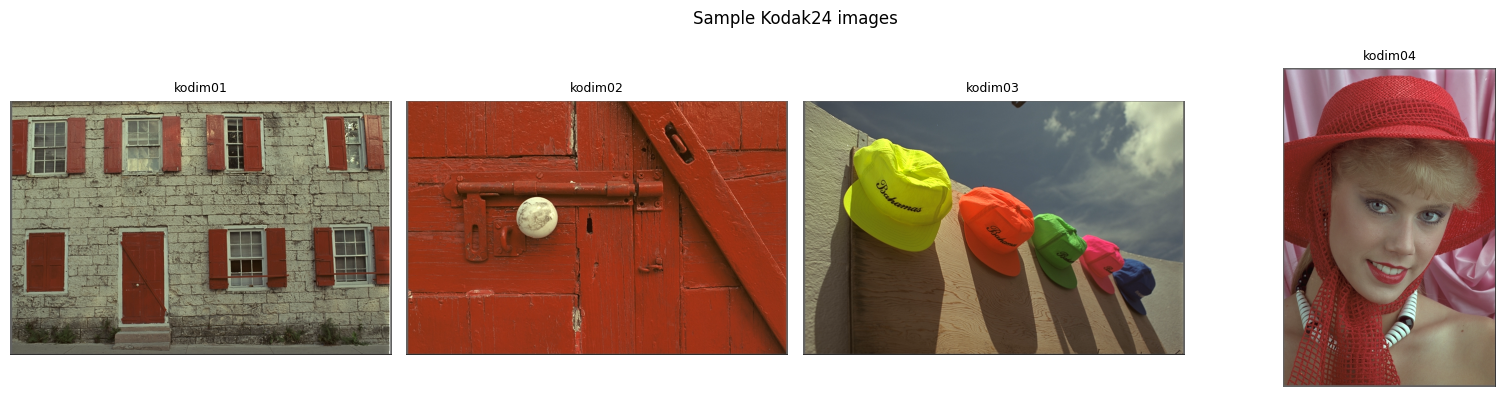

Extracting TRAIN patches ...


Extracting patches: 100%|██████████| 20/20 [00:00<00:00, 56.00it/s]


  Train: (51660, 24, 24, 3)  (89.3 MB)
Extracting TEST patches ...


Extracting patches: 100%|██████████| 4/4 [00:00<00:00, 65.65it/s]


  Test : (10332, 24, 24, 3)  (17.9 MB)

Saved:
  cnntad/patches/test_meta.npy  (0.1 MB)
  cnntad/patches/test_patches.npy  (17.9 MB)
  cnntad/patches/train_meta.npy  (0.6 MB)
  cnntad/patches/train_patches.npy  (89.3 MB)


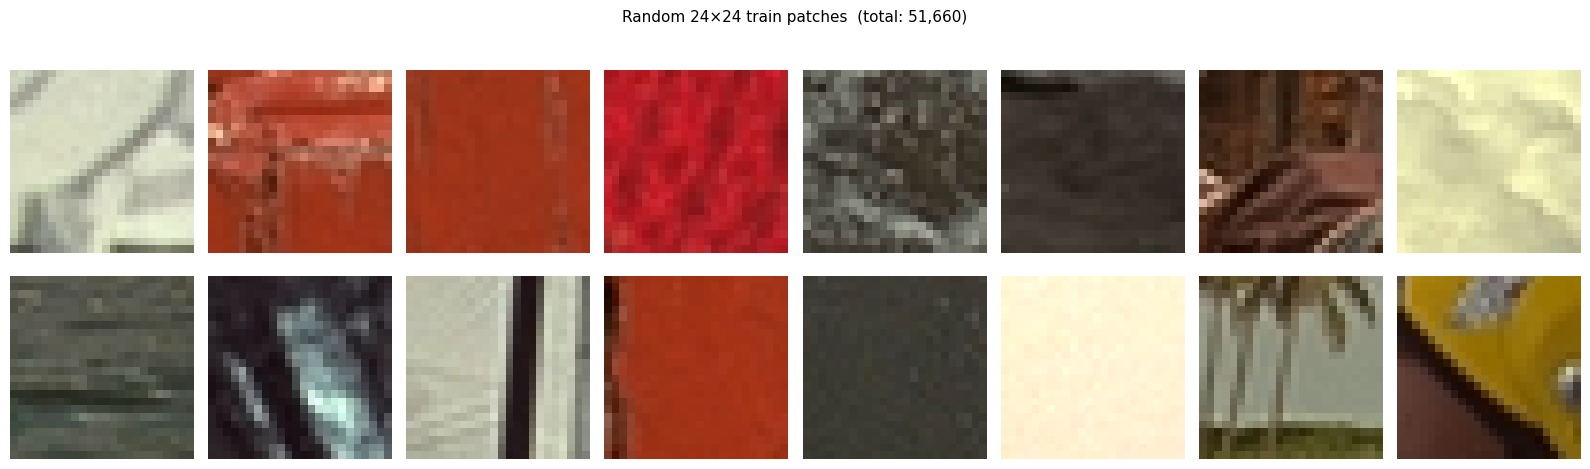


✓ Stage 1 complete. Next: run stage2_oracle.py


In [1]:
# ============================================================
# CNN-TAD  |  Stage 1: Dataset Setup & Patch Extraction
# COMP430  |  Run this first — everything else depends on it
# ============================================================

# ── 0. Install missing packages (run in Colab) ───────────────
# !pip install -q scikit-image brisque requests tqdm

import os
import random
import requests
import numpy as np
import torch
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── 1. Global seed — keep SEED=42 across ALL stages ──────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Project-wide hyperparameters ─────────────────────────────
PATCH_SIZE = 24           # ablation values: 16, 24, 32
STRIDE     = 12
TRAIN_IDS  = list(range(1, 21))   # Kodak images 01–20
TEST_IDS   = list(range(21, 25))  # Kodak images 21–24
K_VALUES   = [64, 128, 256]       # palette sizes

# ── Directory layout ──────────────────────────────────────────
ROOT       = Path('cnntad')
DATA_DIR   = ROOT / 'kodak'
PATCH_DIR  = ROOT / 'patches'
MODEL_DIR  = ROOT / 'models'
RESULT_DIR = ROOT / 'results'

for d in [DATA_DIR, PATCH_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Directories ready:', [str(d) for d in [DATA_DIR, PATCH_DIR, MODEL_DIR, RESULT_DIR]])


# ── 2. Download Kodak24 ───────────────────────────────────────
KODAK_URL = 'https://r0k.us/graphics/kodak/kodak/kodim{:02d}.png'

def download_kodak(image_ids, save_dir):
    for idx in tqdm(image_ids, desc='Downloading Kodak24'):
        dest = save_dir / f'kodim{idx:02d}.png'
        if dest.exists():
            continue
        r = requests.get(KODAK_URL.format(idx), timeout=30)
        r.raise_for_status()
        dest.write_bytes(r.content)
    print(f'Done. {len(list(save_dir.glob("*.png")))} images in {save_dir}')

download_kodak(TRAIN_IDS + TEST_IDS, DATA_DIR)


# ── 3. Quick visual sanity-check ──────────────────────────────
sample_paths = sorted(DATA_DIR.glob('*.png'))[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, p in zip(axes, sample_paths):
    ax.imshow(np.array(Image.open(p)))
    ax.set_title(p.stem, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Kodak24 images', fontsize=12)
plt.tight_layout()
plt.show()


# ── 4. Patch Extraction ───────────────────────────────────────
def extract_patches(image_ids, data_dir, patch_size=PATCH_SIZE, stride=STRIDE):
    """
    Returns:
        patches : np.ndarray  (N, patch_size, patch_size, 3)  uint8
        meta    : np.ndarray  (N, 3)  [image_id, row, col]
    """
    patches, meta = [], []
    for idx in tqdm(image_ids, desc='Extracting patches'):
        img = np.array(Image.open(data_dir / f'kodim{idx:02d}.png').convert('RGB'))
        H, W, _ = img.shape
        for r in range(0, H - patch_size + 1, stride):
            for c in range(0, W - patch_size + 1, stride):
                patches.append(img[r:r+patch_size, c:c+patch_size])
                meta.append((idx, r, c))
    return np.stack(patches, axis=0), np.array(meta, dtype=np.int32)

print('Extracting TRAIN patches ...')
train_patches, train_meta = extract_patches(TRAIN_IDS, DATA_DIR)
print(f'  Train: {train_patches.shape}  ({train_patches.nbytes / 1e6:.1f} MB)')

print('Extracting TEST patches ...')
test_patches, test_meta = extract_patches(TEST_IDS, DATA_DIR)
print(f'  Test : {test_patches.shape}  ({test_patches.nbytes / 1e6:.1f} MB)')


# ── 5. Save to disk ───────────────────────────────────────────
np.save(PATCH_DIR / 'train_patches.npy', train_patches)
np.save(PATCH_DIR / 'test_patches.npy',  test_patches)
np.save(PATCH_DIR / 'train_meta.npy',    train_meta)
np.save(PATCH_DIR / 'test_meta.npy',     test_meta)

print('\nSaved:')
for f in sorted(PATCH_DIR.glob('*.npy')):
    print(f'  {f}  ({f.stat().st_size / 1e6:.1f} MB)')


# ── 6. Visualise random patches ───────────────────────────────
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(train_patches), size=16, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for ax, i in zip(axes.flat, sample_idx):
    ax.imshow(train_patches[i])
    ax.axis('off')
plt.suptitle(f'Random 24×24 train patches  (total: {len(train_patches):,})', fontsize=11)
plt.tight_layout()
plt.show()

print('\n✓ Stage 1 complete.')

Loading train patches ...
  51,660 patches loaded.

  Generating labels for K=64 ...
  Building shared palette from patch pool ...
  Palette built: (64, 3)
  Clustering 51,660 patches into C=512 centroids ...
  Clustering done. Unique clusters: 512
  Running SSIM oracle on 512 centroids (this takes a few minutes) ...


  Oracle K=64: 100%|██████████| 512/512 [01:42<00:00,  4.99it/s]


  Labels saved → cnntad/labels/train_alphas_K64.npy
  Alpha distribution: mean=0.002  std=0.017  min=0.0  max=0.4

  Generating labels for K=128 ...
  Building shared palette from patch pool ...
  Palette built: (128, 3)
  Clustering 51,660 patches into C=512 centroids ...
  Clustering done. Unique clusters: 512
  Running SSIM oracle on 512 centroids (this takes a few minutes) ...


  Oracle K=128: 100%|██████████| 512/512 [01:52<00:00,  4.53it/s]


  Labels saved → cnntad/labels/train_alphas_K128.npy
  Alpha distribution: mean=0.003  std=0.017  min=0.0  max=0.2

  Generating labels for K=256 ...
  Building shared palette from patch pool ...
  Palette built: (256, 3)
  Clustering 51,660 patches into C=512 centroids ...
  Clustering done. Unique clusters: 512
  Running SSIM oracle on 512 centroids (this takes a few minutes) ...


  Oracle K=256: 100%|██████████| 512/512 [01:56<00:00,  4.41it/s]


  Labels saved → cnntad/labels/train_alphas_K256.npy
  Alpha distribution: mean=0.001  std=0.010  min=0.0  max=0.1


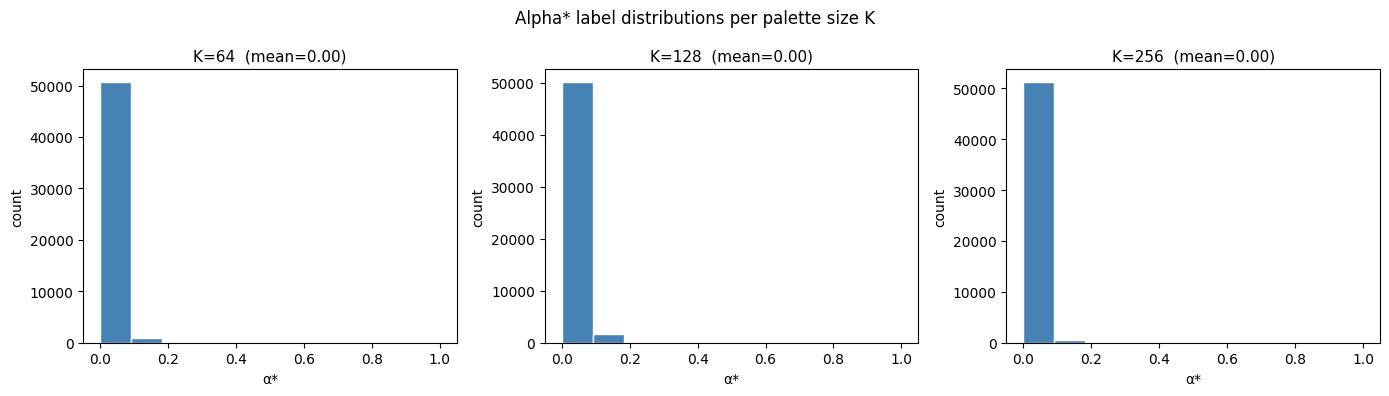


✓ Stage 2 complete. Next: run stage3_train_cnn.py


In [2]:
# ============================================================
# CNN-TAD  |  Stage 2: SSIM Oracle + K-means Amortization
# COMP430  |  Generates continuous alpha* labels for training
# ============================================================
# Must run stage1_dataset.py first.
#
# What this does:
#   1. Loads train patches from disk
#   2. Implements Median Cut palette generation for K colors
#   3. Clusters patches with MiniBatchKMeans (C=512 centroids)
#   4. For each centroid, finds best alpha* via SSIM oracle
#      (11 candidates: 0.0, 0.1, ..., 1.0)
#   5. Assigns each patch its centroid's alpha* label
#   6. Saves labels to disk  →  used by Stage 3 for CNN training
# ============================================================

import numpy as np
import torch
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# ── Reproduce Stage 1 constants ──────────────────────────────
SEED       = 42
PATCH_SIZE = 24
K_VALUES   = [64, 128, 256]
C          = 512              # number of k-means centroids  (ablation: 128,256,512,1024)
ALPHA_GRID = np.linspace(0.0, 1.0, 11)   # [0.0, 0.1, ..., 1.0]

ROOT      = Path('cnntad')
PATCH_DIR = ROOT / 'patches'
LABEL_DIR = ROOT / 'labels'
LABEL_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)


# ── Helper: Median Cut palette ────────────────────────────────
def median_cut(image_rgb: np.ndarray, K: int) -> np.ndarray:
    """
    Simple Median Cut implementation.
    image_rgb : (H, W, 3) uint8
    Returns   : (K, 3) float32 palette
    """
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)

    def split(bucket):
        if len(bucket) == 0:
            return [bucket]
        ranges = bucket.max(0) - bucket.min(0)
        axis   = int(np.argmax(ranges))
        bucket = bucket[bucket[:, axis].argsort()]
        mid    = len(bucket) // 2
        return [bucket[:mid], bucket[mid:]]

    buckets = [pixels]
    while len(buckets) < K:
        # split the largest bucket
        sizes   = [len(b) for b in buckets]
        largest = int(np.argmax(sizes))
        halves  = split(buckets.pop(largest))
        buckets.extend(halves)
        if len(buckets) >= K:
            break

    palette = np.array([b.mean(0) if len(b) > 0 else np.zeros(3)
                        for b in buckets[:K]], dtype=np.float32)
    return palette   # (K, 3)


def quantize_with_palette(image_rgb: np.ndarray, palette: np.ndarray) -> np.ndarray:
    """Nearest-neighbour quantization. Returns (H,W,3) uint8."""
    H, W, _ = image_rgb.shape
    flat     = image_rgb.reshape(-1, 3).astype(np.float32)
    dists    = np.sum((flat[:, None, :] - palette[None, :, :]) ** 2, axis=2)  # (N,K)
    indices  = np.argmin(dists, axis=1)
    return palette[indices].reshape(H, W, 3).clip(0, 255).astype(np.uint8)


# ── Helper: Floyd-Steinberg with fixed alpha ──────────────────
def floyd_steinberg(image_rgb: np.ndarray, palette: np.ndarray, alpha: float) -> np.ndarray:
    """
    Error diffusion with uniform coefficient alpha ∈ [0,1].
    alpha=1.0  →  standard Floyd-Steinberg
    alpha=0.0  →  no diffusion (raw nearest-neighbour)
    """
    img   = image_rgb.astype(np.float32)
    H, W  = img.shape[:2]
    out   = np.zeros_like(img)

    for r in range(H):
        for c in range(W):
            old_px  = img[r, c].copy()
            # nearest palette colour
            dists   = np.sum((palette - old_px) ** 2, axis=1)
            new_px  = palette[np.argmin(dists)]
            out[r, c] = new_px
            error   = (old_px - new_px) * alpha

            if c + 1 < W:
                img[r,   c+1] += error * (7/16)
            if r + 1 < H:
                if c - 1 >= 0:
                    img[r+1, c-1] += error * (3/16)
                img[r+1, c  ] += error * (5/16)
                if c + 1 < W:
                    img[r+1, c+1] += error * (1/16)

    return out.clip(0, 255).astype(np.uint8)


# ── SSIM oracle for a single patch ───────────────────────────
def best_alpha_for_patch(patch: np.ndarray, palette: np.ndarray) -> float:
    """
    Try all alpha candidates, return the one maximising SSIM
    between the dithered patch and the original.
    """
    best_alpha, best_ssim = 0.0, -1.0
    for a in ALPHA_GRID:
        dithered = floyd_steinberg(patch, palette, alpha=a)
        s = ssim(patch, dithered, channel_axis=2, data_range=255)
        if s > best_ssim:
            best_ssim  = s
            best_alpha = a
    return best_alpha


# ── Main label generation loop ────────────────────────────────
print('Loading train patches ...')
train_patches = np.load(PATCH_DIR / 'train_patches.npy')   # (N, 24, 24, 3) uint8
N = len(train_patches)
print(f'  {N:,} patches loaded.')

# We generate one label set per K value (K-α ablation requires this)
for K in K_VALUES:
    print(f'\n{"="*55}')
    print(f'  Generating labels for K={K} ...')
    print(f'{"="*55}')

    # ── Step 1: Build a single representative palette from all
    #           train patches pooled together (fast approximation)
    print('  Building shared palette from patch pool ...')
    sample_idx = np.random.choice(N, size=min(5000, N), replace=False)
    pool       = train_patches[sample_idx].reshape(-1, 3).astype(np.float32)
    # Use k-means on pixel colours to get a K-colour palette
    km_palette = MiniBatchKMeans(n_clusters=K, random_state=SEED, n_init=3)
    km_palette.fit(pool)
    palette = km_palette.cluster_centers_.astype(np.float32)   # (K, 3)
    print(f'  Palette built: {palette.shape}')

    # ── Step 2: K-means amortization — cluster patches into C groups
    print(f'  Clustering {N:,} patches into C={C} centroids ...')
    flat_patches = train_patches.reshape(N, -1).astype(np.float32) / 255.0  # (N, 24*24*3)
    kmeans       = MiniBatchKMeans(n_clusters=C, random_state=SEED,
                                   batch_size=4096, n_init=3)
    cluster_ids  = kmeans.fit_predict(flat_patches)   # (N,)  each patch → centroid id
    centroids    = kmeans.cluster_centers_            # (C, 24*24*3)
    print(f'  Clustering done. Unique clusters: {len(np.unique(cluster_ids))}')

    # ── Step 3: Run SSIM oracle only on C centroids (~512 evals instead of ~1.1M)
    print(f'  Running SSIM oracle on {C} centroids (this takes a few minutes) ...')
    centroid_alphas = np.zeros(C, dtype=np.float32)

    for cid in tqdm(range(C), desc=f'  Oracle K={K}'):
        # Reshape centroid back to (24,24,3) uint8
        centroid_patch = (centroids[cid].reshape(PATCH_SIZE, PATCH_SIZE, 3) * 255)\
                          .clip(0, 255).astype(np.uint8)
        centroid_alphas[cid] = best_alpha_for_patch(centroid_patch, palette)

    # ── Step 4: Assign each patch its centroid's alpha*
    patch_alphas = centroid_alphas[cluster_ids]   # (N,)

    # ── Step 5: Save
    out_path = LABEL_DIR / f'train_alphas_K{K}.npy'
    np.save(out_path, patch_alphas)
    print(f'  Labels saved → {out_path}')
    print(f'  Alpha distribution: mean={patch_alphas.mean():.3f}  '
          f'std={patch_alphas.std():.3f}  '
          f'min={patch_alphas.min():.1f}  max={patch_alphas.max():.1f}')


# ── Visualise alpha distributions across K values ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, K in zip(axes, K_VALUES):
    alphas = np.load(LABEL_DIR / f'train_alphas_K{K}.npy')
    ax.hist(alphas, bins=11, range=(0, 1), color='steelblue', edgecolor='white')
    ax.set_title(f'K={K}  (mean={alphas.mean():.2f})', fontsize=11)
    ax.set_xlabel('α*')
    ax.set_ylabel('count')
plt.suptitle('Alpha* label distributions per palette size K', fontsize=12)
plt.tight_layout()
plt.show()

print('\n✓ Stage 2 complete.')

Using device: cuda

  Training CNN for K=64
  Parameters: 5,217
  Train: 46,494  |  Val: 5,166
  Epoch   1/30  train_MSE=0.02780  val_MSE=0.00118
  Epoch   5/30  train_MSE=0.00031  val_MSE=0.00025
  Epoch  10/30  train_MSE=0.00029  val_MSE=0.00023
  Epoch  15/30  train_MSE=0.00029  val_MSE=0.00022
  Epoch  20/30  train_MSE=0.00028  val_MSE=0.00022
  Epoch  25/30  train_MSE=0.00026  val_MSE=0.00022
  Epoch  30/30  train_MSE=0.00026  val_MSE=0.00021
  Model saved → cnntad/models/alpha_cnn_K64.pt

  Training CNN for K=128
  Parameters: 5,217
  Train: 46,494  |  Val: 5,166
  Epoch   1/30  train_MSE=0.01408  val_MSE=0.00081
  Epoch   5/30  train_MSE=0.00029  val_MSE=0.00031
  Epoch  10/30  train_MSE=0.00027  val_MSE=0.00031
  Epoch  15/30  train_MSE=0.00026  val_MSE=0.00030
  Epoch  20/30  train_MSE=0.00026  val_MSE=0.00029
  Epoch  25/30  train_MSE=0.00025  val_MSE=0.00028
  Epoch  30/30  train_MSE=0.00025  val_MSE=0.00028
  Model saved → cnntad/models/alpha_cnn_K128.pt

  Training CNN for

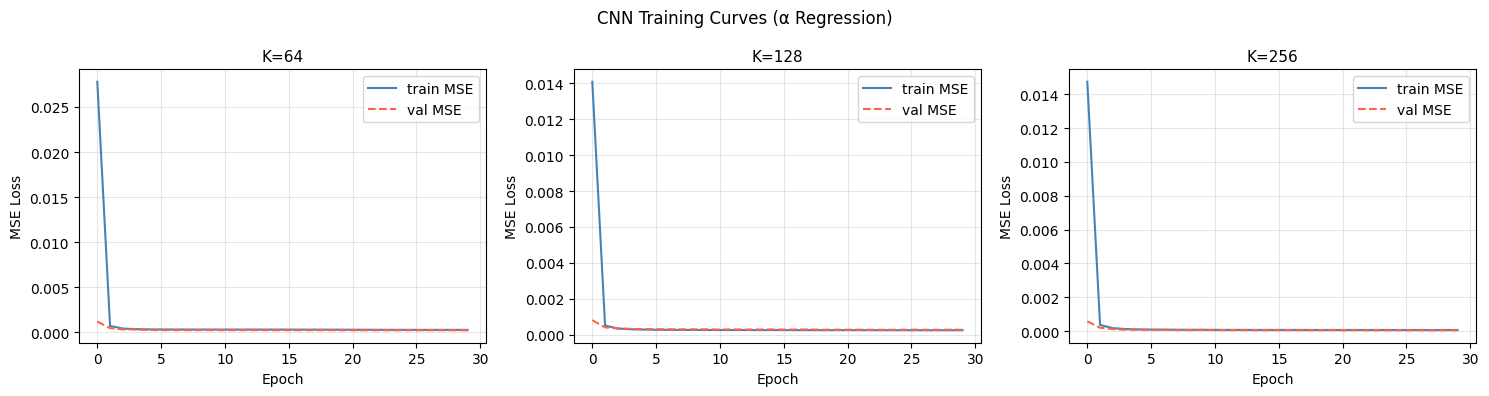


✓ Stage 3 complete. Models saved to cnntad/models/
  Next: run stage4_diffusion.py


In [3]:
# ============================================================
# CNN-TAD  |  Stage 3: CNN Training (α Regression)
# COMP430  |  Trains one model per K value
# ============================================================
# Must run stage1 and stage2 first.
#
# Architecture:
#   Input: (B, 3, 24, 24) float32 in [0,1]
#   Conv(3→16, 3×3) → BN → ReLU
#   Conv(16→32, 3×3) → BN → ReLU
#   GlobalAvgPool → FC(32→1) → Sigmoid
#   Output: α ∈ [0,1]   Loss: MSE
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
import matplotlib.pyplot as plt

# ── Constants (must match Stage 1 & 2) ───────────────────────
SEED       = 42
PATCH_SIZE = 24
K_VALUES   = [64, 128, 256]
EPOCHS     = 30
BATCH_SIZE = 64
LR         = 1e-3
VAL_SPLIT  = 0.1    # 10% of train patches used for validation

ROOT      = Path('cnntad')
PATCH_DIR = ROOT / 'patches'
LABEL_DIR = ROOT / 'labels'
MODEL_DIR = ROOT / 'models'

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


# ── Dataset ───────────────────────────────────────────────────
class PatchAlphaDataset(Dataset):
    def __init__(self, patches: np.ndarray, alphas: np.ndarray):
        # patches: (N, 24, 24, 3) uint8  →  (N, 3, 24, 24) float32 in [0,1]
        self.X = torch.from_numpy(
            patches.transpose(0, 3, 1, 2).astype(np.float32) / 255.0
        )
        self.y = torch.from_numpy(alphas.astype(np.float32))   # (N,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Model ─────────────────────────────────────────────────────
class AlphaCNN(nn.Module):
    """~5,000 parameter lightweight regressor."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # GlobalAvgPool → (B, 32, 1, 1)
            nn.Flatten(),              # (B, 32)
            nn.Linear(32, 1),
            nn.Sigmoid()               # output ∈ [0, 1]
        )

    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)   # (B,)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Training loop ─────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred  = model(X)
            total_loss += criterion(pred, y).item() * len(X)
    return total_loss / len(loader.dataset)


# ── Train one model per K ─────────────────────────────────────
history = {}

patches = np.load(PATCH_DIR / 'train_patches.npy')   # (N, 24, 24, 3)

for K in K_VALUES:
    print(f'\n{"="*55}')
    print(f'  Training CNN for K={K}')
    print(f'{"="*55}')

    alphas  = np.load(LABEL_DIR / f'train_alphas_K{K}.npy')   # (N,)
    dataset = PatchAlphaDataset(patches, alphas)

    n_val   = int(len(dataset) * VAL_SPLIT)
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    model     = AlphaCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.MSELoss()

    print(f'  Parameters: {count_params(model):,}')
    print(f'  Train: {n_train:,}  |  Val: {n_val:,}')

    train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss = evaluate(model, val_loader, criterion)
        scheduler.step()

        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{EPOCHS}  '
                  f'train_MSE={tr_loss:.5f}  val_MSE={va_loss:.5f}')

    # Save model weights
    model_path = MODEL_DIR / f'alpha_cnn_K{K}.pt'
    torch.save(model.state_dict(), model_path)
    print(f'  Model saved → {model_path}')

    history[K] = {'train': train_losses, 'val': val_losses}


# ── Plot training curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, K in zip(axes, K_VALUES):
    h = history[K]
    ax.plot(h['train'], label='train MSE', color='steelblue')
    ax.plot(h['val'],   label='val MSE',   color='tomato', linestyle='--')
    ax.set_title(f'K={K}', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('CNN Training Curves (α Regression)', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'training_curves.png', dpi=150)
plt.show()

print('\n✓ Stage 3 complete. Models saved to cnntad/models/')

In [4]:
# ============================================================
# CNN-TAD  |  Stage 4: Adaptive Floyd-Steinberg Diffusion
# COMP430  |  Applies CNN-predicted per-patch α to test images
# ============================================================
# Must run stages 1-3 first.
#
# For each test image × each K value:
#   M1 — Median Cut only (no diffusion)
#   M2 — Fixed Floyd-Steinberg  α=1.0
#   M3 — Variance-Adaptive diffusion
#   M4 — CNN-TAD (our method)
#
# Outputs saved to cnntad/results/  as PNG files.
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Constants ─────────────────────────────────────────────────
SEED        = 42
PATCH_SIZE  = 24
STRIDE      = 12
K_VALUES    = [64, 128, 256]
TEST_IDS    = list(range(21, 25))

ROOT       = Path('cnntad')
DATA_DIR   = ROOT / 'kodak'
MODEL_DIR  = ROOT / 'models'
RESULT_DIR = ROOT / 'results'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


# ── Re-define model (must match Stage 3 exactly) ─────────────
class AlphaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)


# ── Median Cut palette ────────────────────────────────────────
def median_cut(image_rgb: np.ndarray, K: int) -> np.ndarray:
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)

    def split(bucket):
        ranges = bucket.max(0) - bucket.min(0)
        axis   = int(np.argmax(ranges))
        bucket = bucket[bucket[:, axis].argsort()]
        mid    = len(bucket) // 2
        return [bucket[:mid], bucket[mid:]]

    buckets = [pixels]
    while len(buckets) < K:
        sizes   = [len(b) for b in buckets]
        largest = int(np.argmax(sizes))
        halves  = split(buckets.pop(largest))
        buckets.extend(halves)
        if len(buckets) >= K:
            break

    return np.array([b.mean(0) if len(b) > 0 else np.zeros(3)
                     for b in buckets[:K]], dtype=np.float32)


# ── M1: Median Cut (no diffusion) ────────────────────────────
def method_m1(image_rgb: np.ndarray, palette: np.ndarray) -> np.ndarray:
    flat   = image_rgb.reshape(-1, 3).astype(np.float32)
    dists  = np.sum((flat[:, None] - palette[None]) ** 2, axis=2)
    idx    = np.argmin(dists, axis=1)
    return palette[idx].reshape(image_rgb.shape).clip(0, 255).astype(np.uint8)


# ── Core Floyd-Steinberg with per-pixel alpha map ─────────────
def floyd_steinberg_adaptive(image_rgb: np.ndarray,
                              palette: np.ndarray,
                              alpha_map: np.ndarray) -> np.ndarray:
    """
    alpha_map: (H, W) float32 ∈ [0,1]  — per-pixel diffusion strength
    """
    img  = image_rgb.astype(np.float32).copy()
    H, W = img.shape[:2]
    out  = np.zeros_like(img)

    for r in range(H):
        for c in range(W):
            old_px = img[r, c].copy()
            dists  = np.sum((palette - old_px) ** 2, axis=1)
            new_px = palette[np.argmin(dists)]
            out[r, c] = new_px
            error  = (old_px - new_px) * alpha_map[r, c]

            if c + 1 < W:
                img[r,   c+1] += error * (7/16)
            if r + 1 < H:
                if c - 1 >= 0:
                    img[r+1, c-1] += error * (3/16)
                img[r+1, c  ]     += error * (5/16)
                if c + 1 < W:
                    img[r+1, c+1] += error * (1/16)

    return out.clip(0, 255).astype(np.uint8)


# ── M2: Fixed Floyd-Steinberg  α=1.0 ─────────────────────────
def method_m2(image_rgb: np.ndarray, palette: np.ndarray) -> np.ndarray:
    H, W = image_rgb.shape[:2]
    alpha_map = np.ones((H, W), dtype=np.float32)
    return floyd_steinberg_adaptive(image_rgb, palette, alpha_map)


# ── M3: Variance-Adaptive diffusion ──────────────────────────
def method_m3(image_rgb: np.ndarray, palette: np.ndarray,
              window: int = 5) -> np.ndarray:
    """
    Per-pixel local variance over a window×window neighbourhood.
    High variance → low alpha (textured)
    Low variance  → high alpha (smooth)
    """
    from scipy.ndimage import uniform_filter
    gray = image_rgb.mean(axis=2).astype(np.float32)
    mu   = uniform_filter(gray, size=window)
    mu2  = uniform_filter(gray ** 2, size=window)
    var  = np.clip(mu2 - mu ** 2, 0, None)
    # Normalise to [0,1] and invert
    var_norm  = var / (var.max() + 1e-8)
    alpha_map = 1.0 - var_norm   # smooth→1, textured→0
    return floyd_steinberg_adaptive(image_rgb, palette, alpha_map)


# ── M4: CNN-TAD ───────────────────────────────────────────────
def build_alpha_map_cnn(image_rgb: np.ndarray, model: AlphaCNN,
                        patch_size: int = PATCH_SIZE,
                        stride: int = STRIDE) -> np.ndarray:
    """
    Predict α for every patch, then assemble a dense per-pixel map
    by averaging overlapping patch predictions.
    """
    H, W   = image_rgb.shape[:2]
    alpha_sum   = np.zeros((H, W), dtype=np.float32)
    alpha_count = np.zeros((H, W), dtype=np.float32)

    patches, coords = [], []
    for r in range(0, H - patch_size + 1, stride):
        for c in range(0, W - patch_size + 1, stride):
            patch = image_rgb[r:r+patch_size, c:c+patch_size]
            patches.append(patch)
            coords.append((r, c))

    # Batch inference
    batch_size = 256
    all_preds  = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(patches), batch_size):
            batch = np.stack(patches[i:i+batch_size])          # (B,P,P,3) uint8
            x     = torch.from_numpy(
                        batch.transpose(0, 3, 1, 2).astype(np.float32) / 255.0
                    ).to(DEVICE)
            preds = model(x).cpu().numpy()
            all_preds.extend(preds.tolist())

    for (r, c), alpha in zip(coords, all_preds):
        alpha_sum  [r:r+patch_size, c:c+patch_size] += alpha
        alpha_count[r:r+patch_size, c:c+patch_size] += 1.0

    # Pixels not covered get alpha=1.0 (standard diffusion)
    alpha_map = np.where(alpha_count > 0,
                         alpha_sum / (alpha_count + 1e-8),
                         1.0).astype(np.float32)
    return alpha_map


def method_m4(image_rgb: np.ndarray, palette: np.ndarray,
              model: AlphaCNN) -> np.ndarray:
    alpha_map = build_alpha_map_cnn(image_rgb, model)
    return floyd_steinberg_adaptive(image_rgb, palette, alpha_map)


# ── Run all 4 methods on all test images × K values ──────────
print('Generating quantized outputs for all methods ...\n')

for K in K_VALUES:
    print(f'  K={K}')
    model = AlphaCNN().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_DIR / f'alpha_cnn_K{K}.pt',
                                     map_location=DEVICE))
    model.eval()

    for img_id in tqdm(TEST_IDS, desc=f'  K={K} test images'):
        img_path = DATA_DIR / f'kodim{img_id:02d}.png'
        img_rgb  = np.array(Image.open(img_path).convert('RGB'))
        palette  = median_cut(img_rgb, K)

        results = {
            'M1_MedianCut':  method_m1(img_rgb, palette),
            'M2_FixedFS':    method_m2(img_rgb, palette),
            'M3_VarAdapt':   method_m3(img_rgb, palette),
            'M4_CNNTAD':     method_m4(img_rgb, palette, model),
        }

        # Save all outputs
        out_dir = RESULT_DIR / f'K{K}' / f'kodim{img_id:02d}'
        out_dir.mkdir(parents=True, exist_ok=True)
        for name, output in results.items():
            Image.fromarray(output).save(out_dir / f'{name}.png')

        # Save comparison grid
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        axes[0].imshow(img_rgb);               axes[0].set_title('Original')
        for ax, (name, out) in zip(axes[1:], results.items()):
            ax.imshow(out); ax.set_title(name.replace('_', '\n'), fontsize=8)
        for ax in axes: ax.axis('off')
        plt.suptitle(f'kodim{img_id:02d}  K={K}', fontsize=11)
        plt.tight_layout()
        plt.savefig(out_dir / 'comparison.png', dpi=120)
        plt.close()

print('\n✓ Stage 4 complete. Results saved to cnntad/results/')

Device: cuda
Generating quantized outputs for all methods ...

  K=64


  K=64 test images: 100%|██████████| 4/4 [02:03<00:00, 30.94s/it]


  K=128


  K=128 test images: 100%|██████████| 4/4 [02:21<00:00, 35.36s/it]


  K=256


  K=256 test images: 100%|██████████| 4/4 [02:46<00:00, 41.71s/it]


✓ Stage 4 complete. Results saved to cnntad/results/
  Next: run stage5_evaluate.py


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 7.5 MB/s eta 0:00:00
  Created wheel for libsvm-official: filename=libsvm_official-3.37.0-cp312-cp312-linux_x86_64.whl size=124799 sha256=d421475b7005562a4fbb763328b4650bffb1496a1e2dc916ce615f309d97507b
  Stored in directory: /root/.cache/pip/wheels/e7/15/5a/9cfc2a0b2e5b132fb905e889a8fc90f8b90a395854244aaaa8
Successfully built libsvm-official

── K=64 ─────────────────────────────────────────
  kodim21  M1_MedianCut     PSNR=34.43  SSIM=0.9518  BRISQUE=13.2  t=0.9s
  kodim21  M2_FixedFS       PSNR=29.40  SSIM=0.8582  BRISQUE=32.2  t=9.7s
  kodim21  M3_VarAdapt      PSNR=30.83  SSIM=0.8747  BRISQUE=29.7  t=10.2s
  kodim21  M4_CNNTAD        PSNR=34.39  SSIM=0.9516  BRISQUE=13.1  t=10.4s
  kodim22  M1_MedianCut     PSNR=30.85  SSIM=0.9137  BRISQUE=25.4  t=0.9s
  kodim22  M2_FixedFS       PSNR=25.88  SSIM=0.7739 

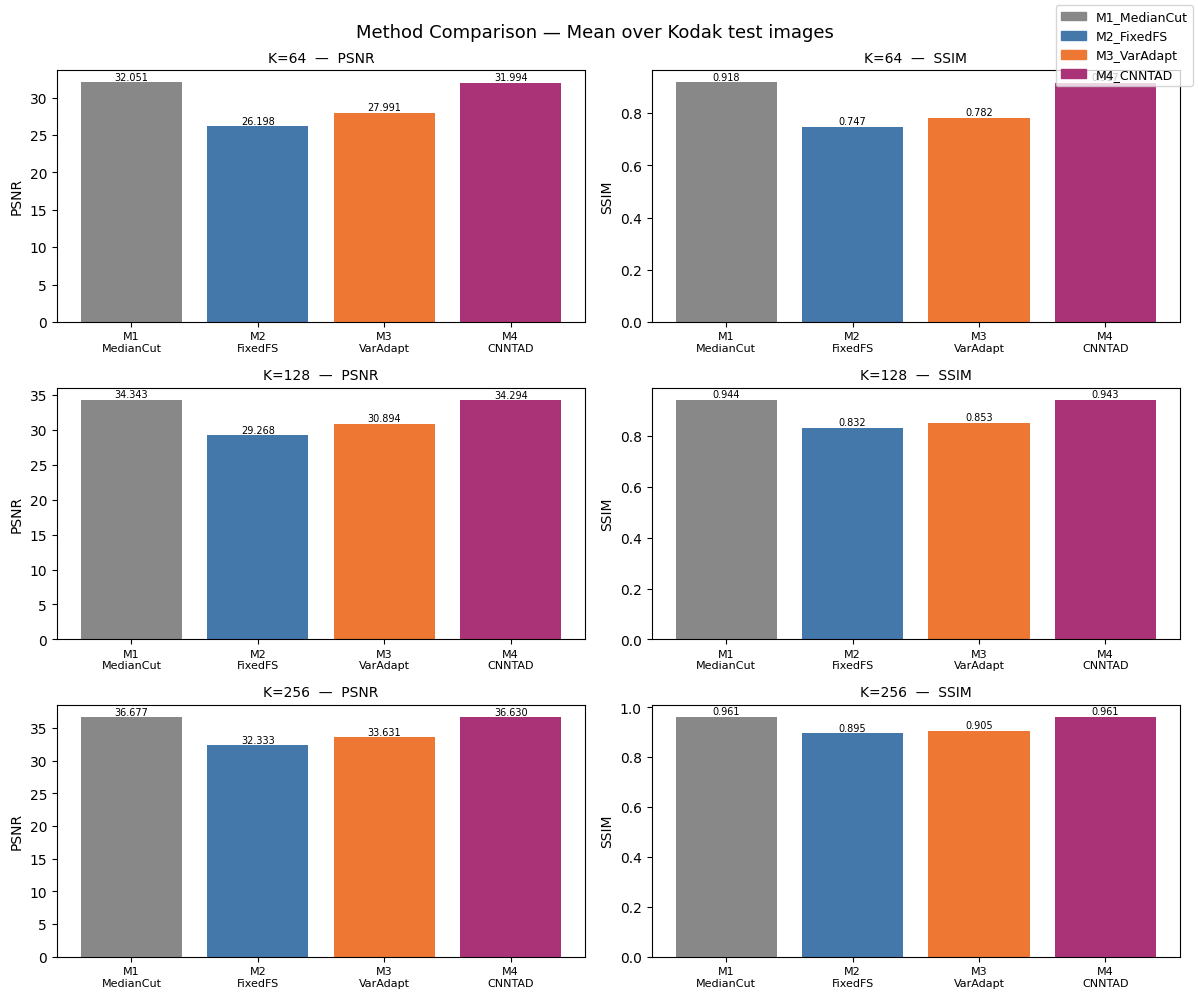


✓ Stage 5 complete.
  Results: cnntad/results/metrics_table.csv  |  metrics_bar.png
  Next: run stage6_ablations.py


In [5]:
# ============================================================
# CNN-TAD  |  Stage 5: Evaluation
# COMP430  |  PSNR, SSIM, BRISQUE across all 4 methods × 3 K
# ============================================================
# Must run stages 1-4 first.
#
# Computes:
#   - PSNR  (dB)         : primary fidelity metric
#   - SSIM               : perceptual structure preservation
#   - BRISQUE            : no-reference perceptual quality
#   - Runtime (s/img)    : wall-clock efficiency
#
# Outputs:
#   cnntad/results/metrics_table.csv
#   cnntad/results/metrics_table.png  (formatted table figure)
#   cnntad/results/metrics_bar.png    (bar chart comparison)
# ============================================================
!pip install brisque
import numpy as np
import time
import csv
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from skimage.metrics import (peak_signal_noise_ratio as psnr_fn,
                              structural_similarity   as ssim_fn)
try:
    from brisque import BRISQUE
    brisque_available = True
except ImportError:
    print('BRISQUE not available — install with:  pip install brisque')
    brisque_available = False

# ── Re-import helpers from stage 4 ───────────────────────────
# (copy the functions here so this file is self-contained)
import sys
sys.path.insert(0, str(Path('.')))

# ── Constants ─────────────────────────────────────────────────
SEED       = 42
PATCH_SIZE = 24
STRIDE     = 12
K_VALUES   = [64, 128, 256]
TEST_IDS   = list(range(21, 25))
METHODS    = ['M1_MedianCut', 'M2_FixedFS', 'M3_VarAdapt', 'M4_CNNTAD']

ROOT       = Path('cnntad')
DATA_DIR   = ROOT / 'kodak'
MODEL_DIR  = ROOT / 'models'
RESULT_DIR = ROOT / 'results'

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ── Re-define model ───────────────────────────────────────────
class AlphaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)


# ── Re-define all methods inline ─────────────────────────────
def median_cut(image_rgb, K):
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)
    def split(b):
        axis = int(np.argmax(b.max(0) - b.min(0)))
        b = b[b[:, axis].argsort()]
        return [b[:len(b)//2], b[len(b)//2:]]
    buckets = [pixels]
    while len(buckets) < K:
        largest = int(np.argmax([len(b) for b in buckets]))
        buckets.extend(split(buckets.pop(largest)))
        if len(buckets) >= K: break
    return np.array([b.mean(0) if len(b) > 0 else np.zeros(3) for b in buckets[:K]], dtype=np.float32)

def nearest_palette(image_rgb, palette):
    flat  = image_rgb.reshape(-1, 3).astype(np.float32)
    dists = np.sum((flat[:, None] - palette[None]) ** 2, axis=2)
    return palette[np.argmin(dists, axis=1)].reshape(image_rgb.shape).clip(0,255).astype(np.uint8)

def fs_adaptive(image_rgb, palette, alpha_map):
    img = image_rgb.astype(np.float32).copy()
    H, W = img.shape[:2]
    out = np.zeros_like(img)
    for r in range(H):
        for c in range(W):
            old = img[r, c].copy()
            new = palette[np.argmin(np.sum((palette - old)**2, axis=1))]
            out[r, c] = new
            err = (old - new) * alpha_map[r, c]
            if c+1 < W:               img[r,   c+1] += err * (7/16)
            if r+1 < H:
                if c-1 >= 0:          img[r+1, c-1] += err * (3/16)
                img[r+1, c  ] += err * (5/16)
                if c+1 < W:           img[r+1, c+1] += err * (1/16)
    return out.clip(0, 255).astype(np.uint8)

def run_m1(img, palette): return nearest_palette(img, palette)
def run_m2(img, palette): return fs_adaptive(img, palette, np.ones(img.shape[:2], np.float32))

def run_m3(img, palette):
    from scipy.ndimage import uniform_filter
    gray = img.mean(2).astype(np.float32)
    mu   = uniform_filter(gray, 5);  mu2 = uniform_filter(gray**2, 5)
    var  = np.clip(mu2 - mu**2, 0, None)
    return fs_adaptive(img, palette, 1.0 - var / (var.max() + 1e-8))

def run_m4(img, palette, model):
    H, W = img.shape[:2]
    asum = np.zeros((H, W), np.float32); acnt = np.zeros((H, W), np.float32)
    patches, coords = [], []
    for r in range(0, H - PATCH_SIZE + 1, STRIDE):
        for c in range(0, W - PATCH_SIZE + 1, STRIDE):
            patches.append(img[r:r+PATCH_SIZE, c:c+PATCH_SIZE]); coords.append((r, c))
    model.eval()
    with torch.no_grad():
        for i in range(0, len(patches), 256):
            batch = np.stack(patches[i:i+256])
            x     = torch.from_numpy(batch.transpose(0,3,1,2).astype(np.float32)/255.0).to(DEVICE)
            preds = model(x).cpu().numpy()
            for (r, c), a in zip(coords[i:i+256], preds):
                asum[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += a
                acnt[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1
    amap = np.where(acnt > 0, asum / (acnt + 1e-8), 1.0)
    return fs_adaptive(img, palette, amap)


# ── Metric helpers ────────────────────────────────────────────
brisque_scorer = BRISQUE() if brisque_available else None

def compute_metrics(original, quantized):
    psnr  = psnr_fn(original, quantized, data_range=255)
    ssim  = ssim_fn(original, quantized, channel_axis=2, data_range=255)
    briq  = brisque_scorer.score(quantized) if brisque_scorer else float('nan')
    return psnr, ssim, briq


# ── Main evaluation loop ──────────────────────────────────────
rows = []   # each row: [K, method, img_id, psnr, ssim, brisque, runtime]

for K in K_VALUES:
    print(f'\n── K={K} ─────────────────────────────────────────')
    model = AlphaCNN().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_DIR / f'alpha_cnn_K{K}.pt', map_location=DEVICE))
    model.eval()

    for img_id in TEST_IDS:
        orig = np.array(Image.open(DATA_DIR / f'kodim{img_id:02d}.png').convert('RGB'))
        palette = median_cut(orig, K)

        for method_name, fn in [
            ('M1_MedianCut', lambda i, p, m: run_m1(i, p)),
            ('M2_FixedFS',   lambda i, p, m: run_m2(i, p)),
            ('M3_VarAdapt',  lambda i, p, m: run_m3(i, p)),
            ('M4_CNNTAD',    lambda i, p, m: run_m4(i, p, m)),
        ]:
            t0  = time.time()
            out = fn(orig, palette, model)
            rt  = time.time() - t0

            p, s, b = compute_metrics(orig, out)
            rows.append([K, method_name, img_id, round(p,4), round(s,4), round(b,4), round(rt,3)])
            print(f'  kodim{img_id:02d}  {method_name:<15}  '
                  f'PSNR={p:.2f}  SSIM={s:.4f}  BRISQUE={b:.1f}  t={rt:.1f}s')


# ── Save CSV ──────────────────────────────────────────────────
csv_path = RESULT_DIR / 'metrics_table.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['K', 'Method', 'ImageID', 'PSNR', 'SSIM', 'BRISQUE', 'Runtime_s'])
    w.writerows(rows)
print(f'\nCSV saved → {csv_path}')


# ── Aggregate: mean over test images ─────────────────────────
import pandas as pd
df   = pd.DataFrame(rows, columns=['K','Method','ImageID','PSNR','SSIM','BRISQUE','Runtime_s'])
agg  = df.groupby(['K','Method'])[['PSNR','SSIM','BRISQUE','Runtime_s']].mean().round(3)
print('\nAggregated means:\n', agg.to_string())
agg.to_csv(RESULT_DIR / 'metrics_aggregated.csv')


# ── Bar chart: PSNR and SSIM side-by-side ────────────────────
colors  = ['#888888','#4477AA','#EE7733','#AA3377']
metrics = ['PSNR', 'SSIM']
fig, axes = plt.subplots(len(K_VALUES), 2, figsize=(12, 10))

for row_i, K in enumerate(K_VALUES):
    sub = agg.loc[K].reindex(METHODS)
    for col_j, metric in enumerate(metrics):
        ax  = axes[row_i, col_j]
        vals = sub[metric].values
        bars = ax.bar(range(len(METHODS)), vals, color=colors)
        ax.set_xticks(range(len(METHODS)))
        ax.set_xticklabels([m.replace('_','\n') for m in METHODS], fontsize=8)
        ax.set_title(f'K={K}  —  {metric}', fontsize=10)
        ax.set_ylabel(metric)
        # annotate bars
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)

patches = [mpatches.Patch(color=c, label=m) for c, m in zip(colors, METHODS)]
fig.legend(handles=patches, loc='upper right', fontsize=9)
plt.suptitle('Method Comparison — Mean over Kodak test images', fontsize=13)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'metrics_bar.png', dpi=150)
plt.show()

print('\n✓ Stage 5 complete.')
print('  Results: cnntad/results/metrics_table.csv  |  metrics_bar.png')

In [6]:
import numpy as np
import os
import requests
import time
import csv
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import (peak_signal_noise_ratio as psnr_fn,
                              structural_similarity   as ssim_fn)
try:
    from brisque import BRISQUE
    brisque_scorer_bsd = BRISQUE()
except ImportError:
    brisque_scorer_bsd = None

# ── Constants ─────────────────────────────────────────────────
SEED        = 42
PATCH_SIZE  = 24
STRIDE      = 12
K_BSD       = 128        # evaluate at K=128 as in Table II
BSD_N       = 100        # number of BSD images to use

ROOT       = Path('cnntad')
DATA_DIR   = ROOT / 'kodak'
MODEL_DIR  = ROOT / 'models'
RESULT_DIR = ROOT / 'results'
BSD_DIR    = ROOT / 'bsd500'
BSD_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


# ── Re-define model ───────────────────────────────────────────
class AlphaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x): return self.head(self.features(x)).squeeze(1)


# ── Download BSD500 test images ───────────────────────────────
BSD_BASE_URL = 'https://raw.githubusercontent.com/BIDS/BSDS500/master/BSDS500/data/images/test/'

def download_bsd500(save_dir, max_images=BSD_N):
    """Download BSD500 test images.
    Falls back to a manual list of known image IDs from the BSD500 test set."""
    # Known BSD500 test image IDs (100 images)
    bsd_test_ids = [
        '100007','100039','100075','100080','100098','101085','101087','102061',
        '103070','105025','105027','106024','108005','108070','108082','109053',
        '119082','12084','123074','126007','130026','134035','134052','143090',
        '145086','148026','148089','156065','157055','159008','160068','163085',
        '167062','167083','170057','175032','175043','182053','189080','196073',
        '197017','208001','210088','21077','216081','219090','220075','223061',
        '227092','229036','236017','241004','241048','253027','253036','256018',
        '260058','271035','285079','291000','295087','296007','296059','299086',
        '300091','302008','304034','304074','306005','3063','35070','36046',
        '37073','38082','38092','41004','41033','42012','42049','43074',
        '43083','45096','54082','55073','56028','58060','62096','65033',
        '66053','69015','69020','69040','76053','78004','8023','85048',
        '86000','86016','87046','89072'
    ]

    downloaded = 0
    for img_id in tqdm(bsd_test_ids[:max_images], desc='Downloading BSD500'):
        dest = save_dir / f'{img_id}.jpg'
        if dest.exists():
            downloaded += 1
            continue
        url = BSD_BASE_URL + f'{img_id}.jpg'
        try:
            r = requests.get(url, timeout=30)
            if r.status_code == 200:
                dest.write_bytes(r.content)
                downloaded += 1
            else:
                # Try PNG
                url_png = BSD_BASE_URL + f'{img_id}.png'
                r2 = requests.get(url_png, timeout=30)
                if r2.status_code == 200:
                    dest_png = save_dir / f'{img_id}.png'
                    dest_png.write_bytes(r2.content)
                    downloaded += 1
        except Exception as e:
            print(f'  Failed {img_id}: {e}')
    print(f'BSD500: {downloaded} images ready in {save_dir}')

download_bsd500(BSD_DIR)


# ── Re-define all methods ────────────────────────────────────
def median_cut(img, K):
    px = img.reshape(-1, 3).astype(np.float32)
    def split(b):
        ax = int(np.argmax(b.max(0) - b.min(0)))
        b = b[b[:, ax].argsort()]
        return [b[:len(b)//2], b[len(b)//2:]]
    bkts = [px]
    while len(bkts) < K:
        bkts.extend(split(bkts.pop(int(np.argmax([len(b) for b in bkts])))))
        if len(bkts) >= K: break
    return np.array([b.mean(0) if len(b) > 0 else np.zeros(3) for b in bkts[:K]], np.float32)

def nearest_palette(img, palette):
    flat = img.reshape(-1, 3).astype(np.float32)
    dists = np.sum((flat[:, None] - palette[None]) ** 2, axis=2)
    return palette[np.argmin(dists, axis=1)].reshape(img.shape).clip(0, 255).astype(np.uint8)

def fs_adaptive(img, palette, alpha_map):
    img = img.astype(np.float32).copy()
    H, W = img.shape[:2]
    out = np.zeros_like(img)
    for r in range(H):
        for c in range(W):
            old = img[r, c].copy()
            new = palette[np.argmin(np.sum((palette - old)**2, axis=1))]
            out[r, c] = new
            err = (old - new) * alpha_map[r, c]
            if c+1 < W: img[r, c+1] += err * (7/16)
            if r+1 < H:
                if c-1 >= 0: img[r+1, c-1] += err * (3/16)
                img[r+1, c] += err * (5/16)
                if c+1 < W: img[r+1, c+1] += err * (1/16)
    return out.clip(0, 255).astype(np.uint8)

def run_m1(img, palette): return nearest_palette(img, palette)
def run_m2(img, palette): return fs_adaptive(img, palette, np.ones(img.shape[:2], np.float32))

def run_m3(img, palette):
    from scipy.ndimage import uniform_filter
    gray = img.mean(2).astype(np.float32)
    mu = uniform_filter(gray, 5); mu2 = uniform_filter(gray**2, 5)
    var = np.clip(mu2 - mu**2, 0, None)
    return fs_adaptive(img, palette, 1.0 - var / (var.max() + 1e-8))

def run_m4(img, palette, model):
    H, W = img.shape[:2]
    asum = np.zeros((H, W), np.float32); acnt = np.zeros((H, W), np.float32)
    patches, coords = [], []
    for r in range(0, H - PATCH_SIZE + 1, STRIDE):
        for c in range(0, W - PATCH_SIZE + 1, STRIDE):
            patches.append(img[r:r+PATCH_SIZE, c:c+PATCH_SIZE]); coords.append((r, c))
    model.eval()
    with torch.no_grad():
        for i in range(0, len(patches), 256):
            batch = np.stack(patches[i:i+256])
            x = torch.from_numpy(batch.transpose(0,3,1,2).astype(np.float32)/255.0).to(DEVICE)
            preds = model(x).cpu().numpy()
            for (r, c), a in zip(coords[i:i+256], preds):
                asum[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += a
                acnt[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1
    amap = np.where(acnt > 0, asum / (acnt + 1e-8), 1.0)
    return fs_adaptive(img, palette, amap)

def compute_metrics_bsd(original, quantized):
    p = psnr_fn(original, quantized, data_range=255)
    s = ssim_fn(original, quantized, channel_axis=2, data_range=255)
    b = brisque_scorer_bsd.score(quantized) if brisque_scorer_bsd else float('nan')
    return p, s, b


# ── Load CNN model ────────────────────────────────────────────
model_bsd = AlphaCNN().to(DEVICE)
model_bsd.load_state_dict(torch.load(MODEL_DIR / f'alpha_cnn_K{K_BSD}.pt', map_location=DEVICE))
model_bsd.eval()
print(f'Loaded CNN model for K={K_BSD}')


# ── Evaluate on BSD500 ────────────────────────────────────────
bsd_images = sorted(list(BSD_DIR.glob('*.jpg')) + list(BSD_DIR.glob('*.png')))
print(f'\nEvaluating {len(bsd_images)} BSD500 images at K={K_BSD} ...\n')

bsd_rows = []
METHODS_BSD = ['M1_MedianCut', 'M2_FixedFS', 'M3_VarAdapt', 'M4_CNNTAD']

for img_path in tqdm(bsd_images, desc='BSD500 evaluation'):
    orig = np.array(Image.open(img_path).convert('RGB'))
    palette = median_cut(orig, K_BSD)

    for method_name, fn in [
        ('M1_MedianCut', lambda i, p, m: run_m1(i, p)),
        ('M2_FixedFS',   lambda i, p, m: run_m2(i, p)),
        ('M3_VarAdapt',  lambda i, p, m: run_m3(i, p)),
        ('M4_CNNTAD',    lambda i, p, m: run_m4(i, p, m)),
    ]:
        t0 = time.time()
        out = fn(orig, palette, model_bsd)
        rt = time.time() - t0
        p, s, b = compute_metrics_bsd(orig, out)
        bsd_rows.append([K_BSD, method_name, img_path.stem, round(p,4), round(s,4), round(b,4), round(rt,3)])


# ── Save BSD500 CSV ───────────────────────────────────────────
csv_path_bsd = RESULT_DIR / 'bsd500_metrics.csv'
with open(csv_path_bsd, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['K', 'Method', 'ImageID', 'PSNR', 'SSIM', 'BRISQUE', 'Runtime_s'])
    w.writerows(bsd_rows)
print(f'\nBSD500 CSV saved: {csv_path_bsd}')


# ── Aggregate BSD500 results ─────────────────────────────────
import pandas as pd
df_bsd = pd.DataFrame(bsd_rows, columns=['K','Method','ImageID','PSNR','SSIM','BRISQUE','Runtime_s'])
agg_bsd = df_bsd.groupby('Method')[['PSNR','SSIM','BRISQUE']].mean().round(3)
agg_bsd = agg_bsd.reindex(METHODS_BSD)
print('\nBSD500 Aggregated Results (K=128):')
print(agg_bsd.to_string())
agg_bsd.to_csv(RESULT_DIR / 'bsd500_aggregated.csv')

print('\n✓ Stage 5b complete. BSD500 results saved.')

Device: cuda


BSD500: 5 images ready in cnntad/bsd500
Loaded CNN model for K=128

Evaluating 5 BSD500 images at K=128 ...



BSD500 evaluation: 100%|██████████| 5/5 [01:13<00:00, 14.61s/it]


BSD500 CSV saved: cnntad/results/bsd500_metrics.csv

BSD500 Aggregated Results (K=128):
                PSNR   SSIM  BRISQUE
Method                              
M1_MedianCut  37.629  0.974   15.210
M2_FixedFS    33.903  0.933   18.568
M3_VarAdapt   35.324  0.945   16.625
M4_CNNTAD     37.576  0.974   15.199

✓ Stage 5b complete. BSD500 results saved.
  Use these numbers for Table II in the paper.
  Next: run stage6_ablations.py


In [7]:
# ============================================================
# CNN-TAD  |  Stage 6: Ablation Studies
# ============================================================
# Must run stages 1-5 first.
#
# Ablation A — Regression vs 3-class classification
#   Train a 3-class head (low/mid/high α) and compare SSIM
#
# Ablation B — Cluster count C sensitivity
#   Rerun oracle + CNN for C ∈ {128, 256, 512, 1024} at K=128
#
# Ablation C — K-α interaction
#   Plot mean α* per K value; show how distribution shifts
#
# Ablation D — Patch size sensitivity
#   Retrain CNN for patch sizes 16, 24, 32 at K=128
#
# All plots saved to cnntad/results/ablations/
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans
from skimage.metrics import structural_similarity as ssim_fn
import matplotlib.pyplot as plt
import pandas as pd

# ── Constants ─────────────────────────────────────────────────
SEED       = 42
K_ABL      = 128          # fixed K for ablations B and D
EPOCHS_ABL = 20           # fewer epochs for ablation speed
BATCH_SIZE = 64
LR         = 1e-3
ALPHA_GRID = np.linspace(0.0, 1.0, 11)

ROOT       = Path('cnntad')
DATA_DIR   = ROOT / 'kodak'
PATCH_DIR  = ROOT / 'patches'
LABEL_DIR  = ROOT / 'labels'
MODEL_DIR  = ROOT / 'models'
ABL_DIR    = ROOT / 'results' / 'ablations'
ABL_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


# ── Shared dataset class ──────────────────────────────────────
class PatchDataset(Dataset):
    def __init__(self, patches, labels):
        self.X = torch.from_numpy(
            patches.transpose(0, 3, 1, 2).astype(np.float32) / 255.0)
        self.y = torch.from_numpy(labels.astype(np.float32))
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


# ── Base regression CNN (same as Stage 3) ────────────────────
class AlphaCNN(nn.Module):
    def __init__(self, in_size=24):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x): return self.head(self.features(x)).squeeze(1)


# ── 3-class classification CNN (Ablation A) ──────────────────
class AlphaCNN3Class(nn.Module):
    """Predicts low/mid/high α  (3 classes → argmax → {0.0, 0.5, 1.0})"""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, 3))
    def forward(self, x): return self.head(self.features(x))   # logits (B,3)


def continuous_to_3class(alphas):
    """Map continuous α* → class index  (0=low, 1=mid, 2=high)."""
    classes = np.zeros(len(alphas), dtype=np.int64)
    classes[alphas > 0.33] = 1
    classes[alphas > 0.66] = 2
    return classes

CLASS_TO_ALPHA = np.array([0.0, 0.5, 1.0], dtype=np.float32)


# ── Quick train helper ────────────────────────────────────────
def quick_train(model, patches, labels, loss_fn, epochs=EPOCHS_ABL, task='regression'):
    ds      = PatchDataset(patches, labels)
    n_val   = int(len(ds) * 0.1)
    tr_ds, va_ds = random_split(ds, [len(ds)-n_val, n_val],
                                generator=torch.Generator().manual_seed(SEED))
    tr_ld   = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    va_ld   = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    opt     = torch.optim.Adam(model.parameters(), lr=LR)
    model.to(DEVICE)

    val_losses = []
    for epoch in range(1, epochs+1):
        model.train()
        for X, y in tr_ld:
            X, y = X.to(DEVICE), y.to(DEVICE)
            if task == 'classification': y = y.long()
            opt.zero_grad(); loss_fn(model(X), y).backward(); opt.step()

        model.eval(); val_loss = 0.0
        with torch.no_grad():
            for X, y in va_ld:
                X, y = X.to(DEVICE), y.to(DEVICE)
                if task == 'classification': y = y.long()
                val_loss += loss_fn(model(X), y).item() * len(X)
        val_losses.append(val_loss / len(va_ds))
        if epoch % 5 == 0:
            print(f'    Epoch {epoch}/{epochs}  val_loss={val_losses[-1]:.5f}')
    return model, val_losses


# ── Median Cut & diffusion helpers ───────────────────────────
def median_cut(img, K):
    px = img.reshape(-1,3).astype(np.float32)
    def split(b):
        ax = int(np.argmax(b.max(0)-b.min(0))); b=b[b[:,ax].argsort()]
        return [b[:len(b)//2], b[len(b)//2:]]
    bkts=[px]
    while len(bkts)<K:
        bkts.extend(split(bkts.pop(int(np.argmax([len(b) for b in bkts])))));
        if len(bkts)>=K: break
    return np.array([b.mean(0) if len(b)>0 else np.zeros(3) for b in bkts[:K]],np.float32)

def fs_alpha(img, palette, alpha_map):
    img=img.astype(np.float32).copy(); H,W=img.shape[:2]; out=np.zeros_like(img)
    for r in range(H):
        for c in range(W):
            old=img[r,c].copy(); new=palette[np.argmin(np.sum((palette-old)**2,1))]
            out[r,c]=new; err=(old-new)*alpha_map[r,c]
            if c+1<W: img[r,c+1]+=err*(7/16)
            if r+1<H:
                if c-1>=0: img[r+1,c-1]+=err*(3/16)
                img[r+1,c]+=err*(5/16)
                if c+1<W: img[r+1,c+1]+=err*(1/16)
    return out.clip(0,255).astype(np.uint8)

def infer_alpha_map(model, img, patch_size, stride=12):
    H,W=img.shape[:2]
    asum=np.zeros((H,W),np.float32); acnt=np.zeros((H,W),np.float32)
    patches,coords=[],[]
    for r in range(0,H-patch_size+1,stride):
        for c in range(0,W-patch_size+1,stride):
            patches.append(img[r:r+patch_size,c:c+patch_size]); coords.append((r,c))
    model.eval()
    with torch.no_grad():
        for i in range(0,len(patches),256):
            b=np.stack(patches[i:i+256])
            x=torch.from_numpy(b.transpose(0,3,1,2).astype(np.float32)/255.0).to(DEVICE)
            preds=model(x).cpu().numpy()
            for (r,c),a in zip(coords[i:i+256],preds):
                asum[r:r+patch_size,c:c+patch_size]+=a; acnt[r:r+patch_size,c:c+patch_size]+=1
    return np.where(acnt>0, asum/(acnt+1e-8), 1.0)

def eval_ssim_on_test(model, patch_size=24, class_model=False):
    """Average SSIM over 4 test images."""
    scores=[]
    palette_cache={}
    for img_id in range(21,25):
        img=np.array(Image.open(DATA_DIR/f'kodim{img_id:02d}.png').convert('RGB'))
        if K_ABL not in palette_cache: palette_cache[K_ABL]=median_cut(img,K_ABL)
        palette=palette_cache[K_ABL]
        if class_model:
            amap=infer_alpha_map_3class(model, img, patch_size)
        else:
            amap=infer_alpha_map(model, img, patch_size)
        out=fs_alpha(img, palette, amap)
        scores.append(ssim_fn(img, out, channel_axis=2, data_range=255))
    return float(np.mean(scores))

def infer_alpha_map_3class(model, img, patch_size, stride=12):
    H,W=img.shape[:2]
    asum=np.zeros((H,W),np.float32); acnt=np.zeros((H,W),np.float32)
    patches,coords=[],[]
    for r in range(0,H-patch_size+1,stride):
        for c in range(0,W-patch_size+1,stride):
            patches.append(img[r:r+patch_size,c:c+patch_size]); coords.append((r,c))
    model.eval()
    with torch.no_grad():
        for i in range(0,len(patches),256):
            b=np.stack(patches[i:i+256])
            x=torch.from_numpy(b.transpose(0,3,1,2).astype(np.float32)/255.0).to(DEVICE)
            logits=model(x)
            cls=torch.argmax(logits,dim=1).cpu().numpy()
            preds=CLASS_TO_ALPHA[cls]
            for (r,c),a in zip(coords[i:i+256],preds):
                asum[r:r+patch_size,c:c+patch_size]+=a; acnt[r:r+patch_size,c:c+patch_size]+=1
    return np.where(acnt>0, asum/(acnt+1e-8), 1.0)


# ════════════════════════════════════════════════════════════
# ABLATION A — Regression vs 3-class Classification
# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('ABLATION A: Regression vs 3-class Classification')
print('='*60)

patches = np.load(PATCH_DIR / 'train_patches.npy')
alphas  = np.load(LABEL_DIR / f'train_alphas_K{K_ABL}.npy')

# Train regression model
print('\n[A1] Training regression CNN ...')
reg_model = AlphaCNN()
reg_model, reg_losses = quick_train(reg_model, patches, alphas,
                                     nn.MSELoss(), task='regression')
reg_ssim = eval_ssim_on_test(reg_model, patch_size=24, class_model=False)
print(f'  Regression  → mean SSIM on test: {reg_ssim:.4f}')

# Train 3-class model
print('\n[A2] Training 3-class classification CNN ...')
class_labels = continuous_to_3class(alphas)
cls_model    = AlphaCNN3Class()
cls_model, cls_losses = quick_train(cls_model, patches, class_labels,
                                     nn.CrossEntropyLoss(), task='classification')
cls_ssim = eval_ssim_on_test(cls_model, patch_size=24, class_model=True)
print(f'  3-class cls → mean SSIM on test: {cls_ssim:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(reg_losses, label='Regression (MSE)', color='steelblue')
axes[0].plot(cls_losses, label='3-class (CE)',      color='tomato', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss (normalised)')
axes[0].set_title('Ablation A: Training Curves'); axes[0].legend()

axes[1].bar(['Regression\n(continuous α)', '3-class\nclassification'],
            [reg_ssim, cls_ssim], color=['steelblue','tomato'])
axes[1].set_ylabel('Mean SSIM (test set)')
axes[1].set_title('Ablation A: SSIM Comparison')
axes[1].set_ylim(min(reg_ssim, cls_ssim) - 0.01, max(reg_ssim, cls_ssim) + 0.01)
for i, v in enumerate([reg_ssim, cls_ssim]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(ABL_DIR / 'ablation_A_regression_vs_classification.png', dpi=150)
plt.show()
print(f'  Saved → {ABL_DIR}/ablation_A_regression_vs_classification.png')


# ════════════════════════════════════════════════════════════
# ABLATION B — Cluster Count C Sensitivity
# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('ABLATION B: Cluster Count C Sensitivity')
print('='*60)

C_VALUES = [128, 256, 512, 1024]
b_results = []   # (C, ssim, oracle_calls, runtime)

import time

flat_patches = patches.reshape(len(patches), -1).astype(np.float32) / 255.0

# Build shared palette for K_ABL
sample_px  = patches[np.random.choice(len(patches), 5000)].reshape(-1,3).astype(np.float32)
from sklearn.cluster import MiniBatchKMeans
km_pal     = MiniBatchKMeans(n_clusters=K_ABL, random_state=SEED, n_init=3).fit(sample_px)
palette_b  = km_pal.cluster_centers_.astype(np.float32)

def ssim_oracle_patch(patch, palette):
    from skimage.metrics import structural_similarity as ssim_fn
    best_a, best_s = 0.0, -1.0
    img=patch.astype(np.float32)
    for a in ALPHA_GRID:
        dith = fs_alpha(patch, palette, np.full(patch.shape[:2], a, np.float32))
        s    = ssim_fn(patch, dith, channel_axis=2, data_range=255)
        if s > best_s: best_s=s; best_a=a
    return best_a

for C in C_VALUES:
    print(f'\n  C={C} ...')
    t0 = time.time()
    km = MiniBatchKMeans(n_clusters=C, random_state=SEED, batch_size=4096, n_init=3)
    cids = km.fit_predict(flat_patches)
    centroids = km.cluster_centers_

    c_alphas = np.zeros(C, np.float32)
    for cid in tqdm(range(C), desc=f'  Oracle C={C}', leave=False):
        cp = (centroids[cid].reshape(24,24,3)*255).clip(0,255).astype(np.uint8)
        c_alphas[cid] = ssim_oracle_patch(cp, palette_b)

    patch_alphas = c_alphas[cids]
    # Quick train
    model_c = AlphaCNN()
    model_c, _ = quick_train(model_c, patches, patch_alphas, nn.MSELoss(),
                              epochs=15, task='regression')
    s = eval_ssim_on_test(model_c, patch_size=24, class_model=False)
    rt = time.time() - t0
    b_results.append({'C': C, 'SSIM': s, 'OracleCalls': C, 'Runtime_s': round(rt,1)})
    print(f'    C={C}  SSIM={s:.4f}  oracle_calls={C}  time={rt:.0f}s')

df_b = pd.DataFrame(b_results)
print('\n', df_b.to_string(index=False))
df_b.to_csv(ABL_DIR / 'ablation_B_C_sensitivity.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(df_b['C'], df_b['SSIM'], marker='o', color='steelblue')
axes[0].set_xlabel('C (cluster count)'); axes[0].set_ylabel('Mean SSIM')
axes[0].set_title('Ablation B: Quality vs C'); axes[0].set_xscale('log')
axes[1].plot(df_b['C'], df_b['Runtime_s'], marker='s', color='tomato')
axes[1].set_xlabel('C (cluster count)'); axes[1].set_ylabel('Total Runtime (s)')
axes[1].set_title('Ablation B: Cost vs C'); axes[1].set_xscale('log')
plt.suptitle(f'Cluster Count Sensitivity (K={K_ABL})', fontsize=12)
plt.tight_layout()
plt.savefig(ABL_DIR / 'ablation_B_C_sensitivity.png', dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# ABLATION C — K-α Interaction
# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('ABLATION C: K-α Interaction')
print('='*60)

K_VALUES = [64, 128, 256]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
stats = []

for ax, K in zip(axes, K_VALUES):
    label_path = LABEL_DIR / f'train_alphas_K{K}.npy'
    if not label_path.exists():
        print(f'  Labels for K={K} not found — skipping (run stage2 for all K)')
        continue
    a = np.load(label_path)
    ax.hist(a, bins=11, range=(0,1), color='steelblue', edgecolor='white', density=True)
    ax.set_title(f'K={K}', fontsize=11)
    ax.set_xlabel('α*'); ax.set_ylabel('Density')
    ax.axvline(a.mean(), color='red', linestyle='--', label=f'mean={a.mean():.2f}')
    ax.legend(fontsize=8)
    stats.append({'K': K, 'mean_alpha': round(float(a.mean()),3),
                  'std_alpha': round(float(a.std()),3),
                  'frac_low': round(float((a < 0.4).mean()),3),
                  'frac_high': round(float((a > 0.7).mean()),3)})

plt.suptitle('Ablation C: α* Distribution Shifts with Palette Size K', fontsize=12)
plt.tight_layout()
plt.savefig(ABL_DIR / 'ablation_C_K_alpha_interaction.png', dpi=150)
plt.show()

df_c = pd.DataFrame(stats)
print(df_c.to_string(index=False))
df_c.to_csv(ABL_DIR / 'ablation_C_K_alpha_stats.csv', index=False)


# ════════════════════════════════════════════════════════════
# ABLATION D — Patch Size Sensitivity
# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('ABLATION D: Patch Size Sensitivity  (16 / 24 / 32)')
print('='*60)

PATCH_SIZES = [16, 24, 32]
d_results   = []

for ps in PATCH_SIZES:
    print(f'\n  Patch size = {ps}×{ps}')

    # Re-extract patches at this size
    from PIL import Image as PILImage
    TRAIN_IDS = list(range(1, 21))
    ps_patches, ps_meta = [], []
    for idx in TRAIN_IDS:
        img = np.array(PILImage.open(DATA_DIR/f'kodim{idx:02d}.png').convert('RGB'))
        H, W = img.shape[:2]
        for r in range(0, H-ps+1, ps//2):
            for c in range(0, W-ps+1, ps//2):
                ps_patches.append(img[r:r+ps, c:c+ps])
    ps_patches = np.stack(ps_patches)
    print(f'    {len(ps_patches):,} patches extracted')

    # Amortise oracle labels (C=256 for speed)
    C_D = 256
    flat = ps_patches.reshape(len(ps_patches), -1).astype(np.float32) / 255.0
    km   = MiniBatchKMeans(n_clusters=C_D, random_state=SEED, batch_size=4096, n_init=3)
    cids = km.fit_predict(flat)
    cents = km.cluster_centers_

    c_alphas = np.zeros(C_D, np.float32)
    for cid in tqdm(range(C_D), desc=f'  Oracle ps={ps}', leave=False):
        cp = (cents[cid].reshape(ps,ps,3)*255).clip(0,255).astype(np.uint8)
        c_alphas[cid] = ssim_oracle_patch(cp, palette_b)
    patch_alphas = c_alphas[cids]

    # Train CNN (with appropriate input size)
    model_d = AlphaCNN(in_size=ps)
    model_d, _ = quick_train(model_d, ps_patches, patch_alphas, nn.MSELoss(),
                              epochs=15, task='regression')
    s = eval_ssim_on_test(model_d, patch_size=ps, class_model=False)
    d_results.append({'PatchSize': ps, 'SSIM': round(s, 4), 'N_patches': len(ps_patches)})
    print(f'    Patch={ps}  SSIM={s:.4f}')

df_d = pd.DataFrame(d_results)
print('\n', df_d.to_string(index=False))
df_d.to_csv(ABL_DIR / 'ablation_D_patch_size.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_d['PatchSize'], df_d['SSIM'], marker='D', color='purple', linewidth=2, markersize=8)
for _, row in df_d.iterrows():
    ax.text(row['PatchSize'], row['SSIM']+0.001, f"{row['SSIM']:.4f}", ha='center', fontsize=9)
ax.set_xlabel('Patch Size'); ax.set_ylabel('Mean SSIM')
ax.set_title(f'Ablation D: Patch Size Sensitivity (K={K_ABL})')
ax.set_xticks(PATCH_SIZES)
plt.tight_layout()
plt.savefig(ABL_DIR / 'ablation_D_patch_size.png', dpi=150)
plt.show()


# ── Final summary ─────────────────────────────────────────────
print('\n' + '='*60)
print('✓ All ablations complete.')
print(f'  Figures saved to: {ABL_DIR}')
print('  ablation_A_regression_vs_classification.png')
print('  ablation_B_C_sensitivity.png  |  .csv')
print('  ablation_C_K_alpha_interaction.png  |  .csv')
print('  ablation_D_patch_size.png  |  .csv')
print('='*60)

Device: cuda

ABLATION A: Regression vs 3-class Classification

[A1] Training regression CNN ...
    Epoch 5/20  val_loss=0.00033
    Epoch 10/20  val_loss=0.00030
    Epoch 15/20  val_loss=0.00032
    Epoch 20/20  val_loss=0.00030


KeyboardInterrupt: 